End-to-End Sales Forecasting & Demand Intelligence System


In [1]:
#IMPORTING LIBRARIES

#Data Manipulation

import pandas as pd 
import numpy as np

#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Configure plots
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid")

#Ignore warnings
import warnings
warnings.filterwarnings("ignore")

Task 1 — Data Loading, Merging & Deep Exploration

In [2]:
#Load the dataset (Superstore Sales Dataset)
df = pd.read_csv("data/train.csv")

#Display first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
#Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [4]:
#Statistical Summary (descriptive summary)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,9800.0,4900.500000,2829.160653,1.000,2450.750,4900.50,7350.250,9800.00
Postal Code,9789.0,55273.322403,32041.223413,1040.000,23223.000,58103.00,90008.000,99301.00
Sales,9800.0,230.769059,626.651875,0.444,17.248,54.49,210.605,22638.48


In [5]:
#Missing value analysis (check for null values in every feature)

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})
missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
Postal Code,11,0.112245
Row ID,0,0.000000
Order ID,0,0.000000
Order Date,0,0.000000
Ship Mode,0,0.000000
Ship Date,0,0.000000
Customer Name,0,0.000000
Segment,0,0.000000
Country,0,0.000000
Customer ID,0,0.000000


In [6]:
#Duplicate record analysis (Identify duplicate record analysis)

duplicates = df.duplicated().sum()  
print(f"Duplicate Records : {duplicates}")

Duplicate Records : 0


In [7]:
#Checking date format in order date and ship date

df[["Order Date", "Ship Date"]].head(10)

,Order Date,Ship Date
0,08/11/2017,11/11/2017
1,08/11/2017,11/11/2017
2,12/06/2017,16/06/2017
3,11/10/2016,18/10/2016
4,11/10/2016,18/10/2016
5,09/06/2015,14/06/2015
6,09/06/2015,14/06/2015
7,09/06/2015,14/06/2015
8,09/06/2015,14/06/2015
9,09/06/2015,14/06/2015


In [8]:
#Check for invalid dates

pd.to_datetime(
    df["Order Date"],
    format="%d/%m/%Y",
    errors="coerce"
).isna().sum()

np.int64(0)

In [9]:
#Display problematic rows

invalid_dates = df[
    pd.to_datetime(
        df["Order Date"],
        format="%d/%m/%Y",
        errors="coerce"
    ).isna()
]

invalid_dates[["Order Date"]].head(20)

,Order Date


In [10]:
#Date Parsing (converting order date and ship date into datetime format)

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed",
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="mixed",
    dayfirst=True
)

In [11]:
#Check data types of Order Date and Ship Date after date parsing

df[["Order Date", "Ship Date"]].dtypes


Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [12]:
#Display first 5 rows after date parsing

df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [13]:
#Feature Engineering 
#Extracting time based features from Order Date column

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Week"] = df["Order Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

In [14]:
#Season

def get_season(month):
    if month in[12,1,2]:
        return "Winter"
    elif month in[3,4,5]:
        return "Spring"
    elif month in[6,7,8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)


In [15]:
#Shipping Time
#Shipping duration between order placement and shipment

df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [16]:
#Weekly & Monthly Aggregation
#Weekly sales

weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [17]:
#Monthly sales

monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq = "M"))["Sales"]
    .sum()
    .reset_index()
)
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


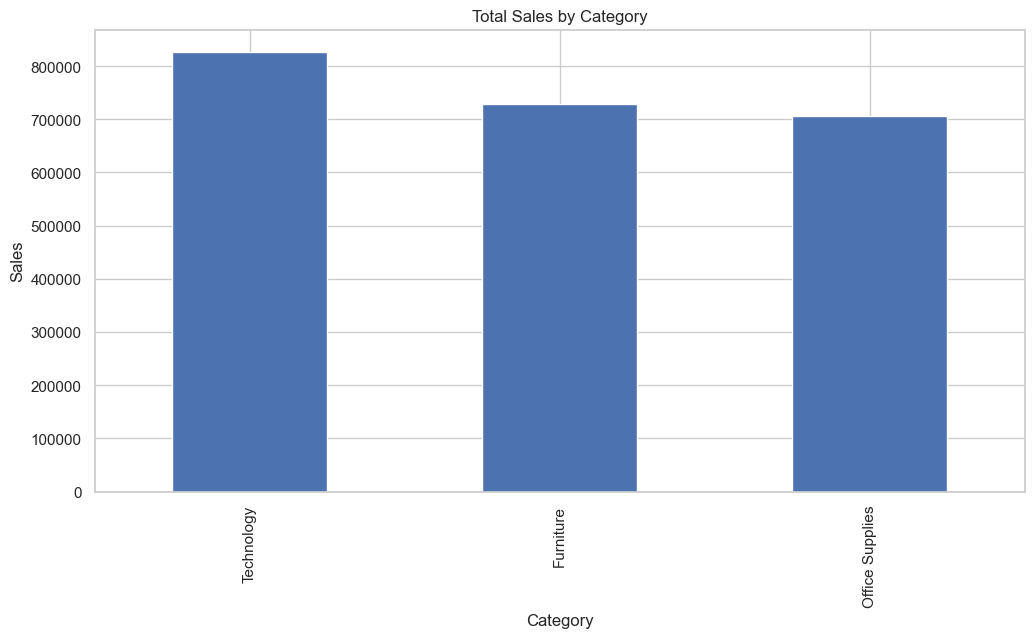

In [18]:
#Exploratory Data Analysis (EDA)
#Category wise sales

category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)
category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.show()

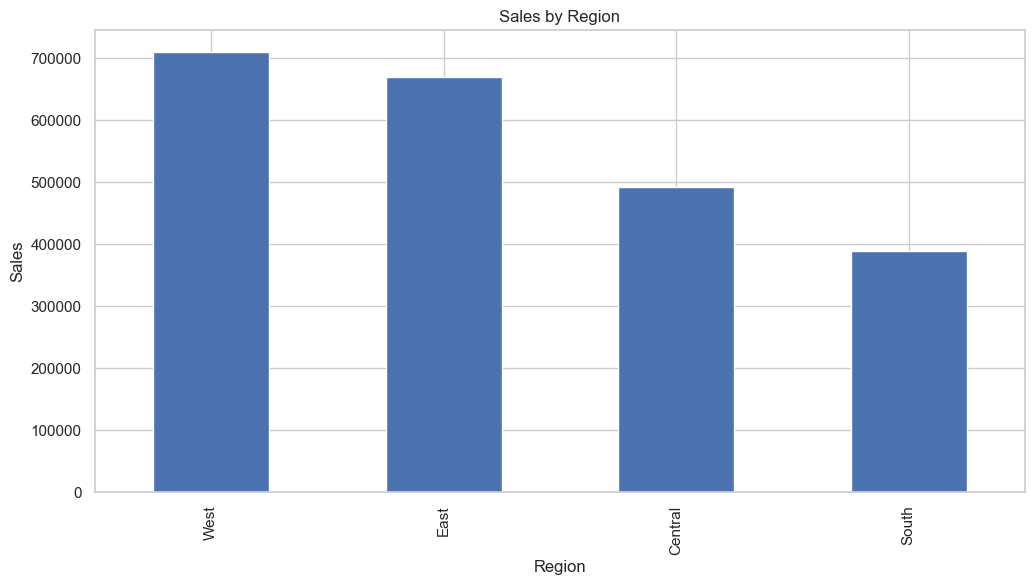

In [19]:
#Region-wise sales

region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

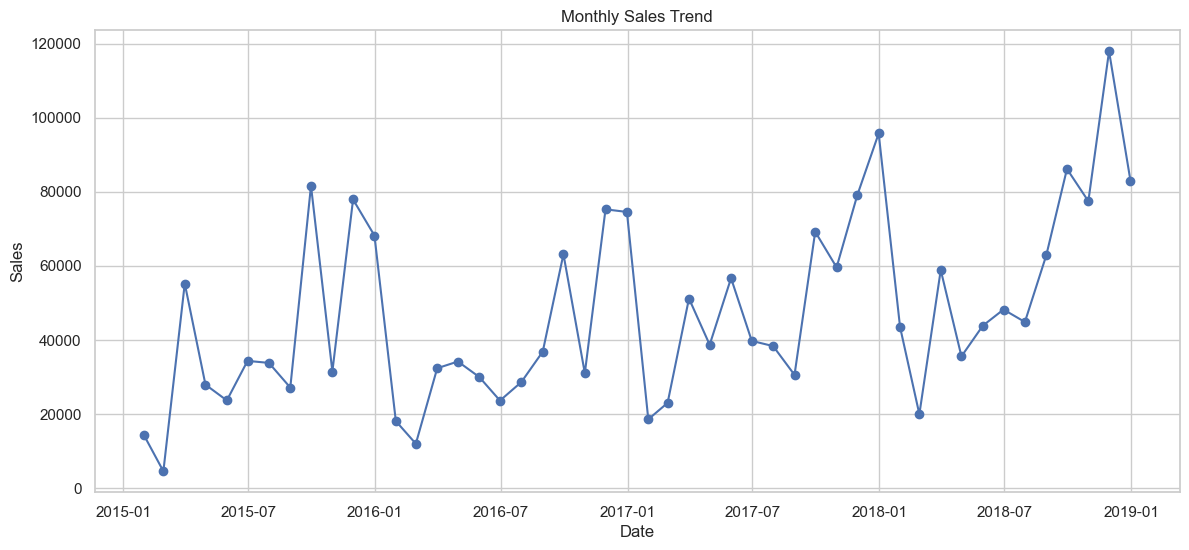

In [20]:
#Monthly sales trend

plt.figure(figsize=(14,6))
plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker = "o"
)
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

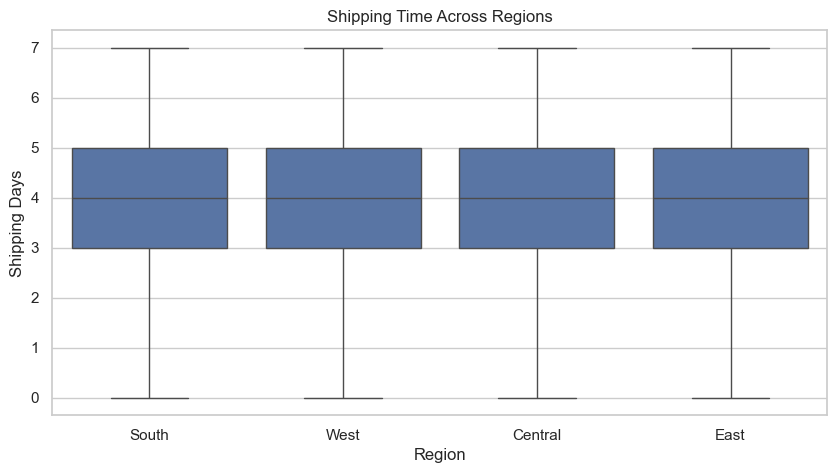

In [21]:
#Shipping time by region

plt.figure(figsize=(10,5))
sns.boxplot(
    x="Region",
    y="Shipping Days",
    data = df
)
plt.title("Shipping Time Across Regions")
plt.show()

Buisness Questions


# 1. Which category genrates highest revenue? 
- category_sales
- Technology generates the highest overall revenue, followed by Furniture and Office Supplies.

# 2. Which region has the most consistent sales growth?

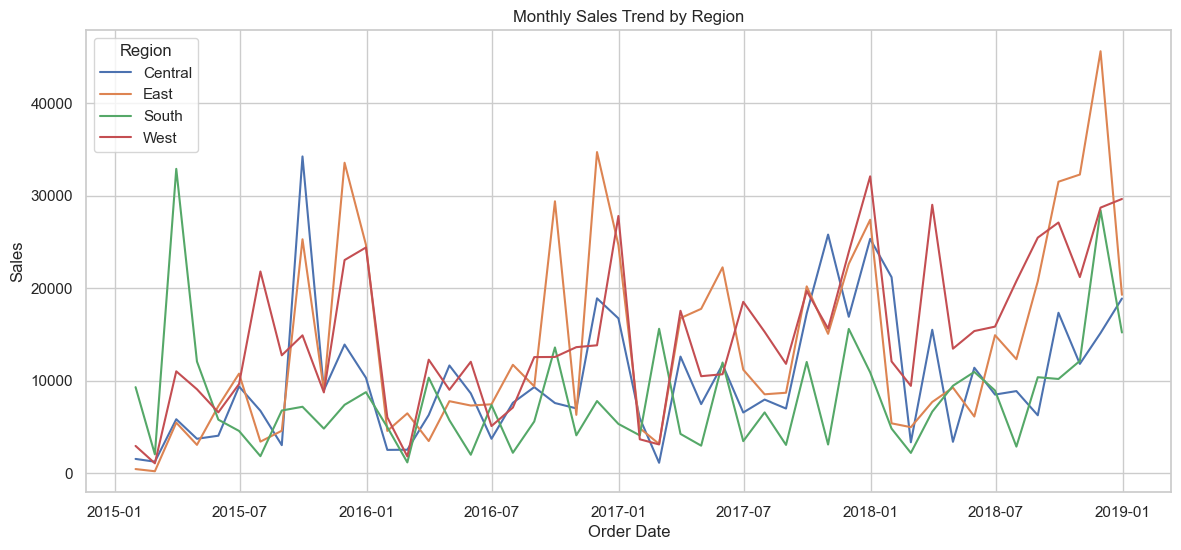

In [22]:

regional_monthly = (
    df.groupby([
        pd.Grouper(key="Order Date", freq ="M"),
        "Region"
    ])["Sales"]
    .sum()
    .reset_index()
)
plt.figure(figsize=(14,6))
sns.lineplot(
    data = regional_monthly,
    x ="Order Date",
    y = "Sales",
    hue = "Region"
)
plt.title("Monthly Sales Trend by Region")
plt.show()


The west region demonstrates the most consistent upward sales trend over the four-year period.

# 3. What is the average time between Order Date and Ship Date — and does vary by region?

In [23]:

df.groupby("Region")["Shipping Days"].mean().sort_values()

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

# 4. Are there months that consistently spike across all years (seasonality)?


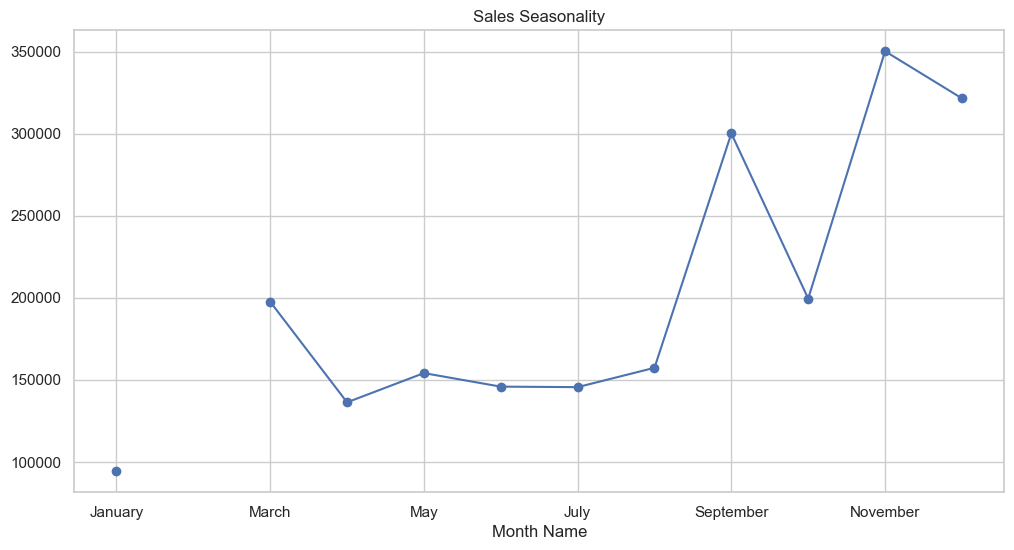

In [24]:

seasonality = (
    df.groupby("Month Name")["Sales"]
    .sum()
    .reindex([
        "January","Feburary","March","April","May","June","July","August",
        "September","October","November","December"
    ])
)
seasonality.plot(marker="o")
plt.title("Sales Seasonality")
plt.show()

Task 1 Summary

- Successfully loaded and cleaned the Superstore Sales dataset.

- Converted data columns into datetime format.

- Created additional temporal features including Year, Month, Week, Quarter, Day, and Season.

- Calculated shipping duration for each transaction.

- Aggregated sales into weekly and monthly levels for future forecasting.

- Identified sales distribution across product categories and regions.

- Examoned shipping performance across different regions.

- Explored monthly sales trends and seasonal behaviour.

Task 2 — Time Series Analysis & Decomposition

In [25]:
#Monthly sales time series

monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq = "ME"))["Sales"]
    .sum()
    .reset_index()
)
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


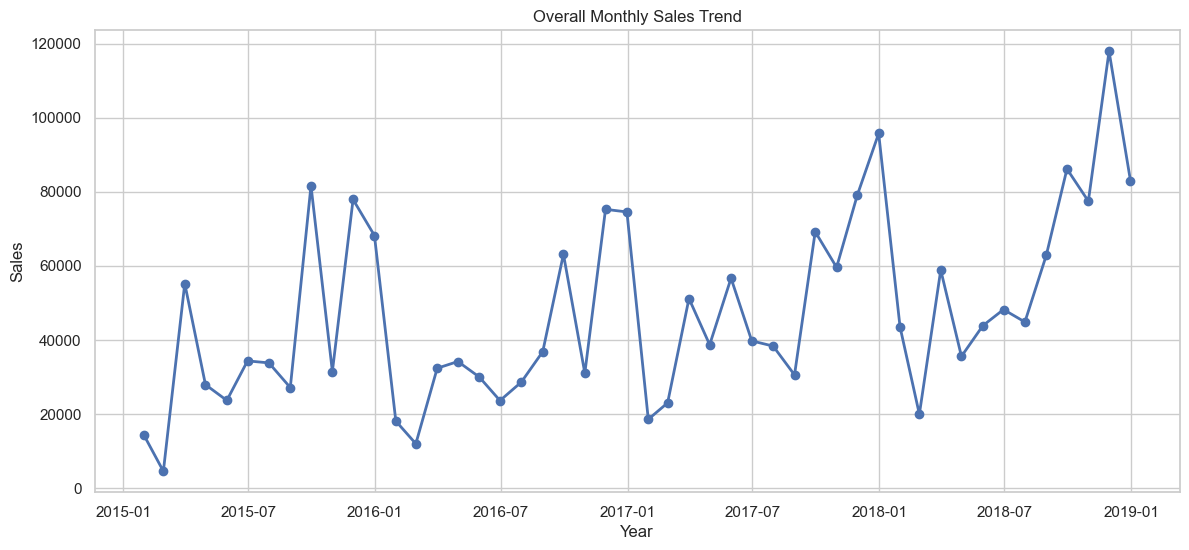

In [26]:
#Monthly sales trend
#Visualize the overall sales trend over 4 years period

plt.figure(figsize=(14,6))
plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Overall Monthly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

In [27]:
#Set date as index

monthly_sales.set_index("Order Date", inplace=True)
monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [28]:
#Time Series decomposition
#decompose monthly sales time series into: Trend, Seasonal, Residual

from statsmodels.tsa.seasonal import seasonal_decompose
decomposiiton = seasonal_decompose(
    monthly_sales["Sales"],
    model= "additive",
    period=12
)

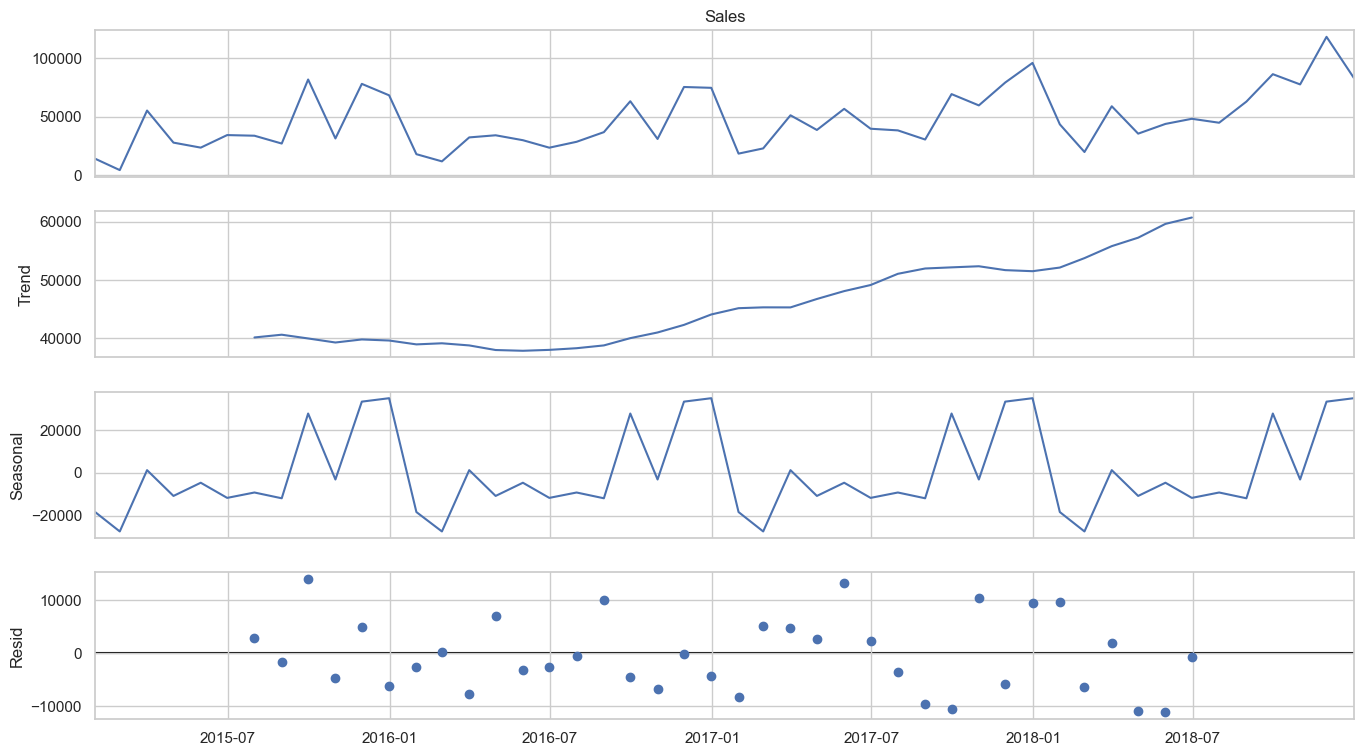

In [29]:
#Plot decomposition

fig = decomposiiton.plot()
fig.set_size_inches(14,8)
plt.show()

### Observations

- Trend: Shows the long-term increase or decrease in sales.
- Seasonality: Repeating yearly patterns in monthly sales.
- Residual: Random fluctuations that are not explained by the trend or seasonality.

The decomposition helps determine whether the data contains a strong seasonal pattern, which is important when selecting forecasting models.

In [30]:
#Statinary Test (ADF Test)
#The ADF(Augmented Dickry Fuller) Test checks ehther the time is stationary. 

from statsmodels.tsa.stattools import adfuller
result = adfuller(monthly_sales["Sales"])

print("ADF Statistic :", result[0])
print("p-value :", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623
Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


In [31]:
#Interpret ADF Test

if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is NOT stationary")

The time series is stationary.


### Interpretation
- p-value < 0.05 : The series is stationary.
- p-value >= 0.05 : The series is non-stationary and should be transformed brfore applying many forecasting models.

In [32]:
#Apply differencing

monthly_sales["Differenced Sales"] = (
    monthly_sales["Sales"].diff()
)

monthly_sales.head()

,Sales,Differenced Sales
Order Date,,
2015-01-31,14205.707,NaN
2015-02-28,4519.892,-9685.815
2015-03-31,55205.797,50685.905
2015-04-30,27906.855,-27298.942
2015-05-31,23644.303,-4262.552


In [33]:
#Remove missing values

differenced = monthly_sales["Differenced Sales"].dropna()

In [34]:
#ADF again

result2 = adfuller(differenced)
print("ADF Statistic :", result2[0])
print("p-value :", result2[1])

for key, value in result2[4].items():
    print(f"{key}: {value}")

ADF Statistic : -8.72706183035327
p-value : 3.2669175472796045e-14
1%: -3.626651907578875
5%: -2.9459512825788754
10%: -2.6116707716049383


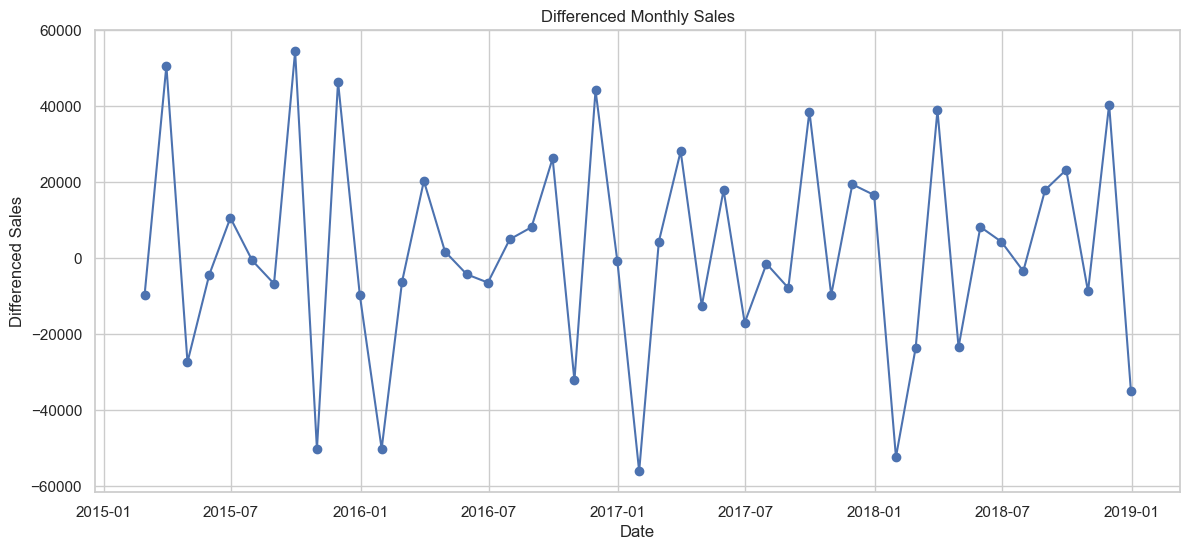

In [35]:
#Plot differenced series

plt.figure(figsize=(14,6))

plt.plot(
    differenced, 
    marker="o"
)
plt.title("Differenced Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Differenced Sales")

plt.grid(True)
plt.show()

In [36]:
#Saving figures

#Monthly sales trend
plt.savefig("charts/monthly_sales_trend.png", dpi=300, bbox_inches="tight")

#Decomposition plot
fig.savefig("charts/time_series_decomposition.png", dpi=300, bbox_inches="tight")

#Differenced series
fig.savefig("charts/differenced_series.png", dpi=300, bbox_inches="tight")

<Figure size 1200x600 with 0 Axes>

Task 2 Summary:

- Monthly sales were aggregated and visualized to observe the long-term trend.
- Time series decompostion separated the sales signal into trend, seasonal, and residual components.
- The ADF test was used to evaluate stationary.
- Since the origina series was non-stationary, first-order differencing was applied.
- The differenced series showed improved stationary, making it more suitable for forecasting models such as SARIMA.

Task 3 — Sales Forecasting using 3 Different Models

Task 3A - SARIMA Forecasting

In [ ]:
#Importing required libraries for building and evaluating SARIMA forecasting

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)



In [ ]:
#Previous monthly sales

sales_series = monthly_sales["Sales"]

In [ ]:
#Checking for pervious monthly sales
sales_series.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Name: Sales, dtype: float64

In [ ]:
#Train-Test split (20% daat for testing)

train_size = int(len(sales_series) * 0.80)
train = sales_series[:train_size]
test = sales_series[train_size:]
print("Training Samples :", len(train))
print("Testing Samples :", len(test))


Training Samples : 38
Testing Samples : 10


# SARIMA requires:
- (p,d,q)
- (P,D,Q,m)
- Initially: (1,1,1) & (1,1,1,12)

In [ ]:
#Building model 

sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order= (1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_result = sarima_model.fit()
print(sarima_result.summary())

c:\Users\aanya\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\aanya\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   38
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -118.582
Date:                            Fri, 10 Jul 2026   AIC                            247.163
Time:                                    17:37:44   BIC                            249.153
Sample:                                01-31-2015   HQIC                           245.909
                                     - 02-28-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2499      0.668     -0.374      0.708      -1.559       1.059
ma.L1         -0.9858      0.982   

In [ ]:
#Predicting test data

sarima_predicition = sarima_result.predict(
    start = test.index[0],
    end = test.index[-1]
)

In [ ]:
#Evaluation Metrics (MAE,RMSE amd MAPE)

mae = mean_absolute_error(
    test,
    sarima_predicition
)
rmse = np.sqrt(
    mean_squared_error(
        test,
        sarima_predicition
    )
)
mape = mean_absolute_percentage_error(
    test,
    sarima_predicition
)

print(f"MAE : {mae:2f}")
print(f"RMSE : {rmse:2f}")
print(f"MAPE : {mape:4f}")

MAE : 13455.424213
RMSE : 15938.986007
MAPE : 0.220204


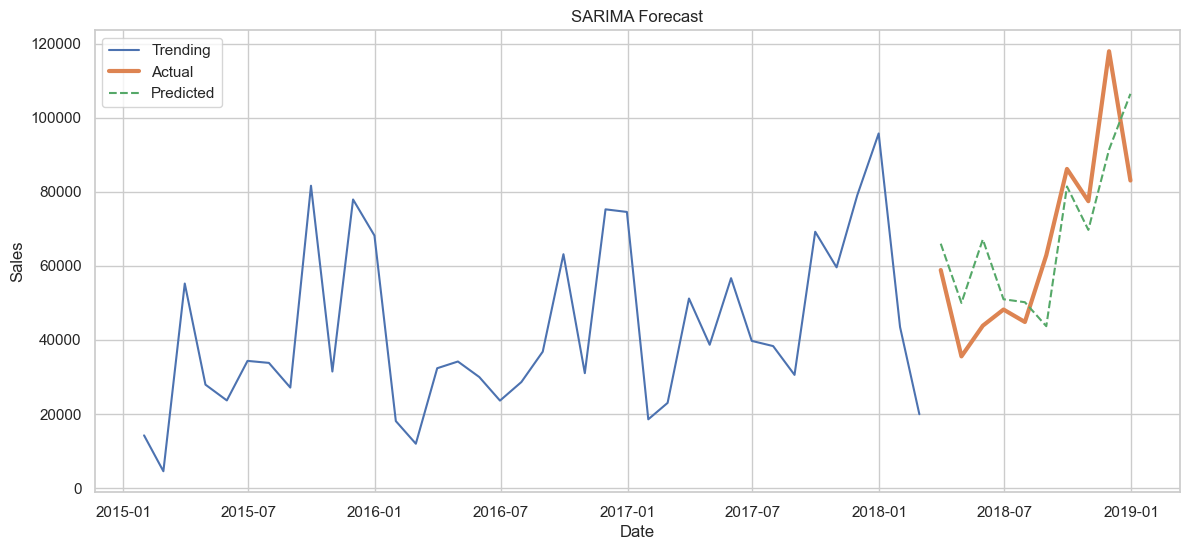

In [ ]:
#Plotting actual vs Predicted

plt.figure(figsize=(14,6))
plt.plot(
    train.index,
    train,
    label="Trending"
)
plt.plot(
    test.index,
    test,
    label="Actual",
    linewidth=3
)
plt.plot(
    test.index,
    sarima_predicition,
    label="Predicted",
    linestyle = "--"
)
plt.title("SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()


In [ ]:
#Forecast for next 3 Months (retrain entire dataset)

final_model = SARIMAX(
    sales_series,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_invertibility=False,
    enforce_stationarity=False
)
final_result = final_model.fit()

c:\Users\aanya\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\aanya\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [ ]:
#forecast

future_forecast = final_result.get_forecast(steps=3)
forecast_df = future_forecast.summary_frame()
forecast_df

Sales,mean,mean_se,mean_ci_lower,mean_ci_upper
2019-01-31,46782.479191,15199.159703,16992.673577,76572.284805
2019-02-28,40285.470518,15658.160379,9596.040110,70974.900926
2019-03-31,72234.203230,15773.426232,41318.855902,103149.550557


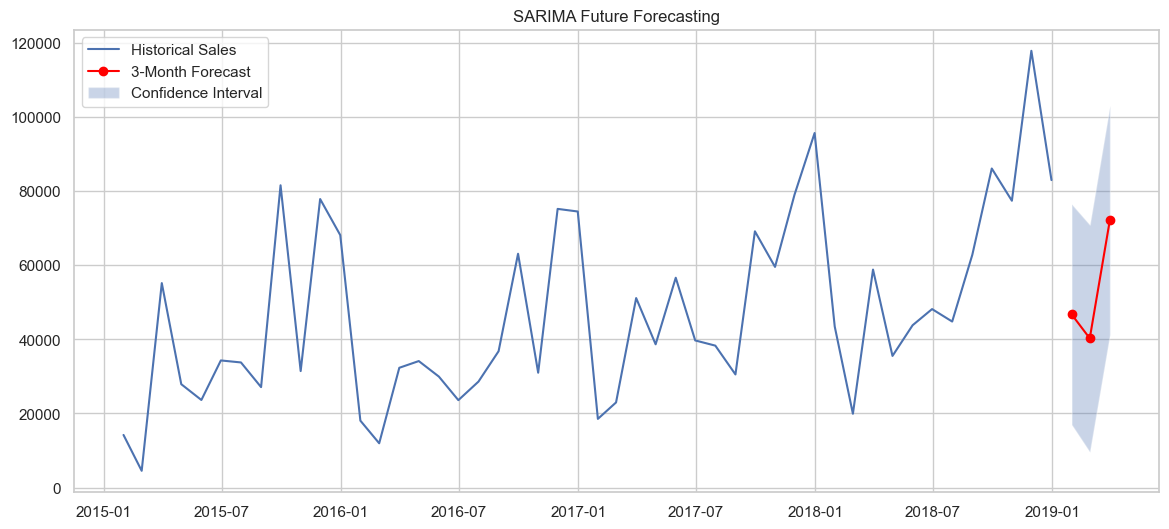

In [ ]:
#Plotting future forecast

plt.figure(figsize=(14,6))
plt.plot(
    sales_series.index,
    sales_series,
    label = "Historical Sales"
)
plt.plot(
    forecast_df.index,
    forecast_df["mean"],
    marker="o",
    color="red",
    label="3-Month Forecast"
)
plt.fill_between(
    forecast_df.index,
    forecast_df["mean_ci_lower"],
    forecast_df["mean_ci_upper"],
    alpha = 0.3,
    label = "Confidence Interval"
)
plt.legend()
plt.title("SARIMA Future Forecasting")
plt.show()

In [ ]:
#Saving figures

plt.savefig(
    "charts/sarima_forecast.png",
    dpi=300,
    bbox_inches = "tight"
)

<Figure size 1200x600 with 0 Axes>

## Buisness Interpretation
## SARIMA Model Interpretation

- The SARIMA model was trained on historical monthly sales data.
- Model performance was evaluated using MAE, RMSE, MAPE on a hold out test set.
- After evaluation, the model was retrained on the complete dataset to generate a 3 month future forecast.
-  The confidence interval highlights the uncertainity with future predictions, allowing decision-makers to assess potential best-case and worst-case demand scenarios.

Task 3B - Prophet Forecasting

In [ ]:
#Import prophet

from prophet import Prophet

In [ ]:
#Prepare data
#ds - data 
#y - target value

prophet_df = monthly_sales.reset_index()[["Order Date", "Sales"]]
prophet_df.columns = ["ds", "y"]
prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
#Train-test split 

train_size = int(len(prophet_df) * 0.80)
train_prophet = prophet_df.iloc[:train_size]
test_prophet = prophet_df.iloc[train_size:]

In [ ]:
#Create Prophet Model

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
prophet_model.fit(train_prophet)

18:31:06 - cmdstanpy - INFO - Chain [1] start processing
18:31:08 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
#Predicting Test Period

future_test = prophet_model.make_future_dataframe(
    periods = len(test_prophet),
    freq="ME"
)
forecast_test = prophet_model.predict(future_test)

In [ ]:
#Evaluation period

predicitions = forecast_test["yhat"].tail(len(test_prophet)).values
actual = test_prophet["y"].values
mae_prophet = mean_absolute_error(actual,predicitions)
rmse_prophet = np.sqrt(mean_squared_error(actual,predicitions))
mape_prophet = mean_absolute_percentage_error(actual,predicitions)

print(f"MAE : {mae_prophet:.2f}")
print(f"RMSE : {rmse_prophet:.2f}")
print(f"MAPE : {mape_prophet:.4f}")

MAE : 10128.56
RMSE : 14561.39
MAPE : 0.1433


In [ ]:
#Train on full dataset

final_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
final_prophet.fit(prophet_df)

18:36:56 - cmdstanpy - INFO - Chain [1] start processing
18:36:56 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
#Forecast next 3 months

future = final_prophet.make_future_dataframe(
    periods = 3,
    freq = "ME"
)
forecast = final_prophet.predict(future)
forecast.tail(3)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
48,2019-01-31,62195.429713,33668.379604,51884.563461,62190.395391,62201.529673,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,0.0,0.0,0.0,42990.532202
49,2019-02-28,62861.958979,22406.900262,41530.401753,62845.239440,62881.383845,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,0.0,0.0,0.0,31248.159922
50,2019-03-31,63599.902094,71367.318257,90427.909568,63567.357094,63638.644815,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,0.0,0.0,0.0,81267.007772


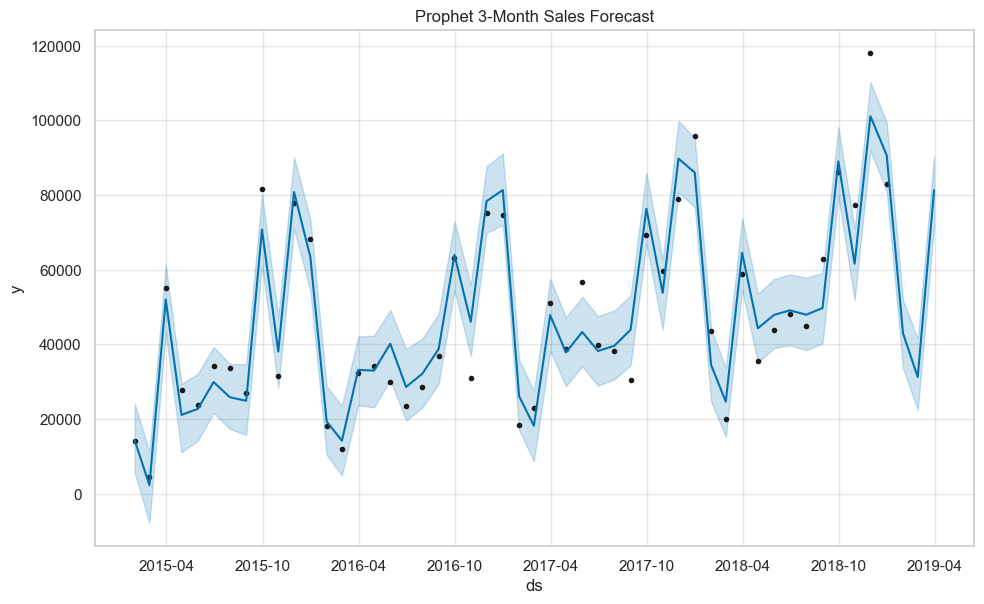

In [ ]:
#Forecast plot

fig1 = final_prophet.plot(forecast)
plt.title("Prophet 3-Month Sales Forecast")
plt.show()

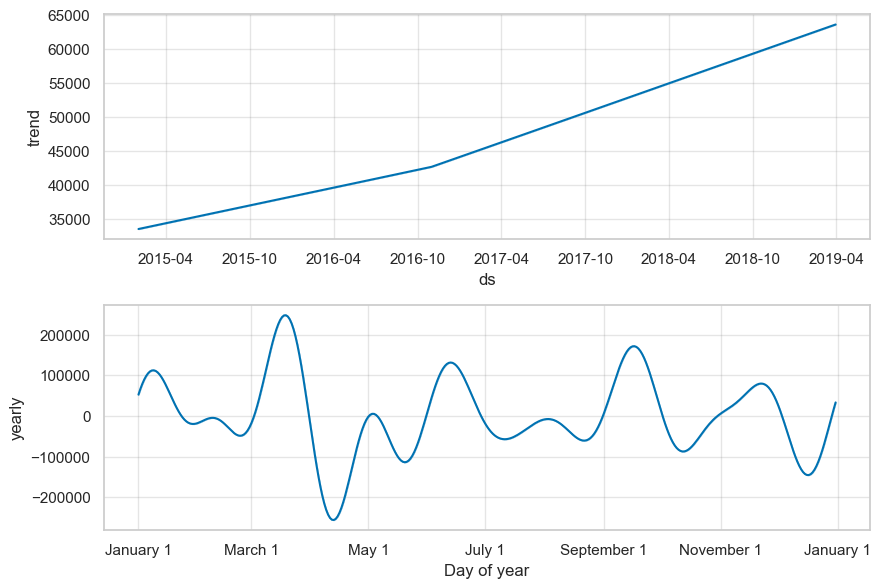

In [ ]:
#Trend and seasonality components

fig2 = final_prophet.plot_components(forecast)
plt.show()

# Buisness Interpretation 
The Prophet model captured the long-term sales trend and yearly seasonal effects. The forecast provides estimated sales for the next three months, while the component plots explain how the underlying trend and seasonality contributr to the predictions, This makes the model easy to interpret for buisness stakeholders